In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)

In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(DATA_DIR / "cars_kmeans.csv", skipinitialspace=True)
df.columns = [c.strip() for c in df.columns]
display(df.head())
display(df.info())

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,brand
0,14.0,8,350.0,165,4209.0,12,1972,Toyota
1,31.9,4,89.0,71,1925.0,14,1980,Honda
2,17.0,8,302.0,140,3449.0,11,1971,Toyota
3,15.0,8,400.0,150,3761.0,10,1971,Toyota
4,30.5,4,98.0,63,2051.0,17,1978,Toyota


<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mpg          261 non-null    float64
 1   cylinders    261 non-null    int64  
 2   cubicinches  259 non-null    float64
 3   hp           261 non-null    int64  
 4   weightlbs    258 non-null    float64
 5   time-to-60   261 non-null    int64  
 6   year         261 non-null    int64  
 7   brand        261 non-null    str    
dtypes: float64(3), int64(4), str(1)
memory usage: 16.4 KB


None

In [3]:
numeric_cols = ["mpg", "cylinders", "cubicinches", "hp", "weightlbs", "time-to-60", "year"]
X = df[numeric_cols].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")

prep = Pipeline(
    steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
)
X_scaled = prep.fit_transform(X)

scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    scores.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X_scaled, labels),
        }
    )

score_df = pd.DataFrame(scores)
display(score_df)

,k,inertia,silhouette
0,2,818.283645,0.486872
1,3,603.852409,0.344735
2,4,476.745419,0.350939
3,5,422.699490,0.301398
4,6,378.254152,0.285729
5,7,344.229840,0.278360
6,8,316.381557,0.270795


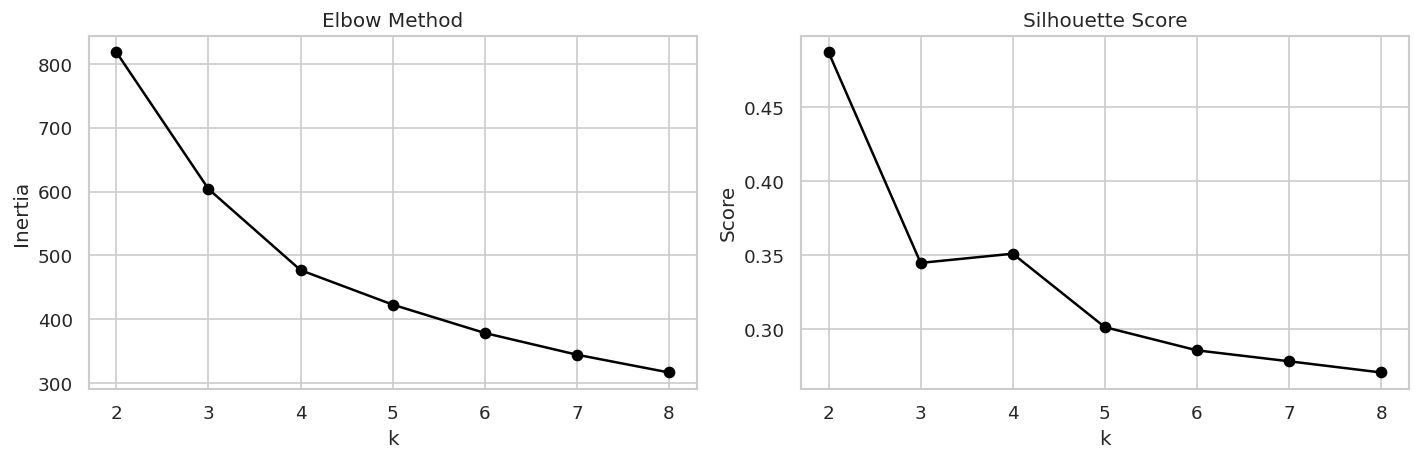

Selected k from silhouette: 2


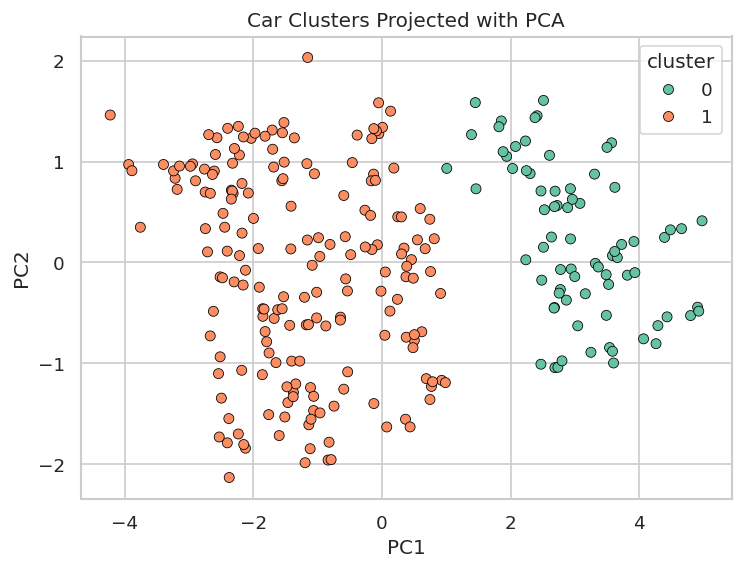

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year
cluster,,,,,,,
0,15.08,7.97,348.17,160.22,4067.96,12.63,1975.00
1,26.46,4.61,139.77,84.23,2567.98,16.75,1977.57


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(score_df["k"], score_df["inertia"], marker="o", color="black")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(score_df["k"], score_df["silhouette"], marker="o", color="black")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

best_k = int(score_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Selected k from silhouette:", best_k)

kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(X_scaled)
clustered = df.copy()
clustered["cluster"] = clusters

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
plot_df["cluster"] = clusters

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", palette="Set2", edgecolor="black")
plt.title("Car Clusters Projected with PCA")
plt.show()

display(clustered.groupby("cluster")[numeric_cols].mean().round(2))